In [2]:
import pandas as pd
import numpy as np
import spacy
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/comentarios_toxicos_ptBR.csv')
df.dropna(subset=['text', 'toxic'], inplace=True)
df.head()

,Unnamed: 0,text,text_norm,toxic
0,12451,brocolis é muito boooom pqp,brócolis boom puta pariu,0
1,4080,to correndo disso,to correndo disso,0
2,5195,presidente da oab sofre amea莽as de morte e aci...,presidente aba sofre ame-a morte aciona polega...,0
3,13375,@user @user aí desanima pq para de vir teus ch...,aí desanima porque vir champ chato pra caralho...,1
4,4130,"ser feio e beta é um bosta, puta que me pariu....",feio beta bosta puta pariu lá vou comprar ócul...,1


In [4]:
nlp = spacy.load("pt_core_news_sm")

def preProcessar(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúâêôãõüç\s]', '', texto)
    doc = nlp(texto)
    return " ".join([token.text for token in doc if not token.is_stop and token.text.strip()])

print("Processando textos (isso pode demorar alguns minutos)...")
if 'text_norm' in df.columns:
    df.dropna(subset=['text_norm'], inplace=True)
    df['text_normalized_str'] = df['text_norm']
else:
    df['text_normalized_str'] = df['text'].apply(preProcessar)

df[['text', 'text_normalized_str', 'toxic']].head()

Processando textos (isso pode demorar alguns minutos)...


,text,text_normalized_str,toxic
0,brocolis é muito boooom pqp,brócolis boom puta pariu,0
1,to correndo disso,to correndo disso,0
2,presidente da oab sofre amea莽as de morte e aci...,presidente aba sofre ame-a morte aciona polega...,0
3,@user @user aí desanima pq para de vir teus ch...,aí desanima porque vir champ chato pra caralho...,1
4,"ser feio e beta é um bosta, puta que me pariu....",feio beta bosta puta pariu lá vou comprar ócul...,1


In [5]:
X = df['text_normalized_str']
y = df['toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 23894
Teste: 5974


In [6]:
tfidf = TfidfVectorizer(max_features=10000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_vec, y_train)
print("Modelo RandomForestClassifier treinado com sucesso!")

Modelo RandomForestClassifier treinado com sucesso!


In [8]:
y_pred = model.predict(X_test_vec)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Tóxico', 'Tóxico']))

Relatório de Classificação:
              precision    recall  f1-score   support

  Não Tóxico       0.82      0.79      0.81      3272
      Tóxico       0.76      0.79      0.77      2702

    accuracy                           0.79      5974
   macro avg       0.79      0.79      0.79      5974
weighted avg       0.79      0.79      0.79      5974



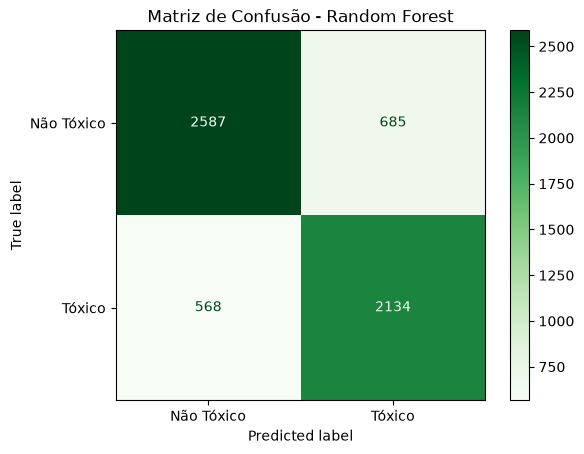

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Tóxico', 'Tóxico'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Matriz de Confusão - Random Forest')
plt.show()

In [10]:
def previsao(text):
    text_processed = preProcessar(text)
    vec = tfidf.transform([text_processed])
    prob = model.predict_proba(vec)[0][1]
    pred = model.predict(vec)[0]
    return pred, prob

In [11]:
testes = [
    "Você é um idiota!",
    "Eu gostei muito desse vídeo.",
    "Que coisa maravilhosa!",
    "Esse cara é muito burro.",
    "Não concordo com você.",
    "Vai para o inferno."
]

for texto in testes:
    resultado, probabilidade = previsao(texto)
    classe = "Tóxico" if resultado == 1 else "Não Tóxico"
    print(f"Texto: '{texto}' | Previsão: {classe} | Prob(Tóxico): {probabilidade:.2%}")

Texto: 'Você é um idiota!' | Previsão: Tóxico | Prob(Tóxico): 74.58%
Texto: 'Eu gostei muito desse vídeo.' | Previsão: Não Tóxico | Prob(Tóxico): 1.64%
Texto: 'Que coisa maravilhosa!' | Previsão: Não Tóxico | Prob(Tóxico): 0.29%
Texto: 'Esse cara é muito burro.' | Previsão: Tóxico | Prob(Tóxico): 98.80%
Texto: 'Não concordo com você.' | Previsão: Não Tóxico | Prob(Tóxico): 0.16%
Texto: 'Vai para o inferno.' | Previsão: Não Tóxico | Prob(Tóxico): 25.56%
